In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 509s 3us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [ ]:
class_names = [
'apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle',
'bicycle','bottle','bowl','boy','bridge','bus','butterfly','camel',
'can','castle','caterpillar','cattle','chair','chimpanzee','clock',
'cloud','cockroach','couch','crab','crocodile','cup','dinosaur',
'dolphin','elephant','flatfish','forest','fox','girl','hamster',
'house','kangaroo','keyboard','lamp','lawn_mower','leopard','lion',
'lizard','lobster','man','maple_tree','motorcycle','mountain',
'mouse','mushroom','oak_tree','orange','orchid','otter','palm_tree',
'pear','pickup_truck','pine_tree','plain','plate','poppy',
'porcupine','possum','rabbit','raccoon','ray','road','rocket',
'rose','sea','seal','shark','shrew','skunk','skyscraper','snail',
'snake','spider','squirrel','streetcar','sunflower','sweet_pepper',
'table','tank','telephone','television','tiger','tractor','train',
'trout','tulip','turtle','wardrobe','whale','willow_tree','wolf',
'woman','worm'
]

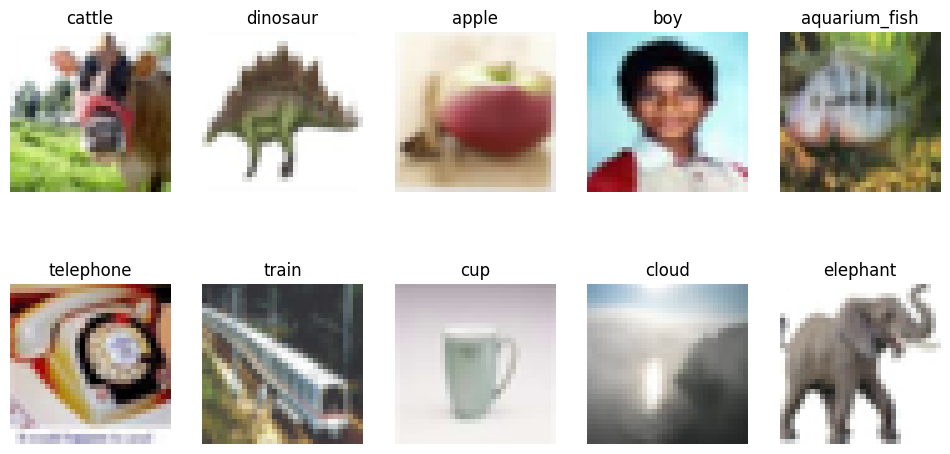

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

In [ ]:
model = Sequential()

# First Convolution Layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

# First Pooling Layer
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Second Pooling Layer
model.add(MaxPooling2D((2,2)))

# Third Convolution Layer
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(256, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(100, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,492 (2.45 MB)

 Trainable params: 643,492 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.0590 - loss: 4.1772 - val_accuracy: 0.1382 - val_loss: 3.6647
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1496 - loss: 3.5973 - val_accuracy: 0.2079 - val_loss: 3.2612
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2015 - loss: 3.2929 - val_accuracy: 0.2550 - val_loss: 3.0497
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2398 - loss: 3.0904 - val_accuracy: 0.2813 - val_loss: 2.8994
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2666 - loss: 2.9298 - val_accuracy: 0.3088 - val_loss: 2.7525
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2912 - loss: 2.7944 - val_accuracy: 0.3305 - val_loss: 2.6602
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3167 - loss: 2.6778 - val_accuracy: 0.3391 - val_loss: 2.6434
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3397 - loss: 2.5666 - val_accuracy: 0

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5594 - loss: 1.5006 - val_accuracy: 0.3825 - val_loss: 2.7512
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5674 - loss: 1.4710 - val_accuracy: 0.3768 - val_loss: 2.8017
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5796 - loss: 1.4211 - val_accuracy: 0.3761 - val_loss: 2.7892
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5892 - loss: 1.3759 - val_accuracy: 0.3732 - val_loss: 2.8448
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5987 - loss: 1.3294 - val_accuracy: 0.3741 - val_loss: 2.9080
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6029 - loss: 1.3096 - val_accuracy: 0.3743 - val_loss: 2.9854
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6112 - loss: 1.2810 - val_accuracy: 0.3743 - val_loss: 3.0000
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6212 - loss: 1.2412 - val_accuracy: 0.

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3895 - loss: 2.5876
Test Loss: 2.587601661682129
Test Accuracy: 0.3894999921321869


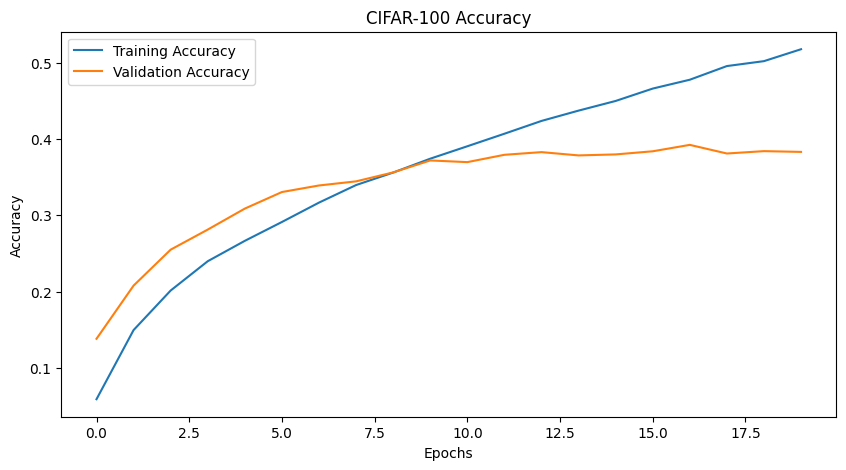

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CIFAR-100 Accuracy')
plt.legend()

plt.show()

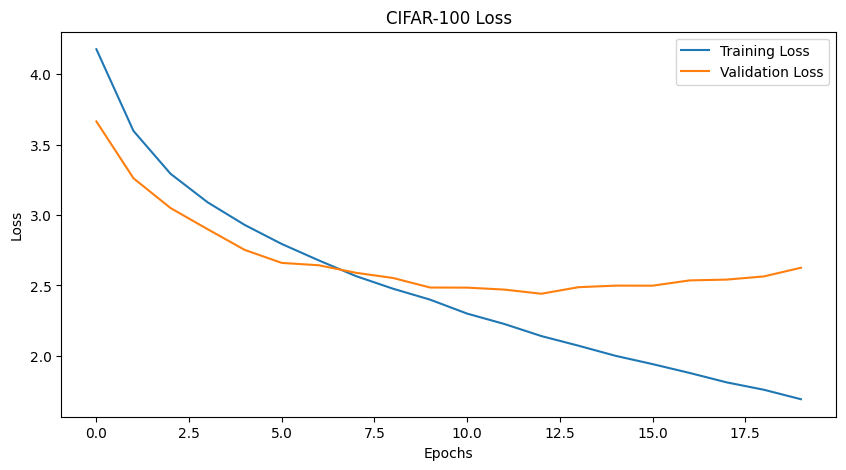

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CIFAR-100 Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step


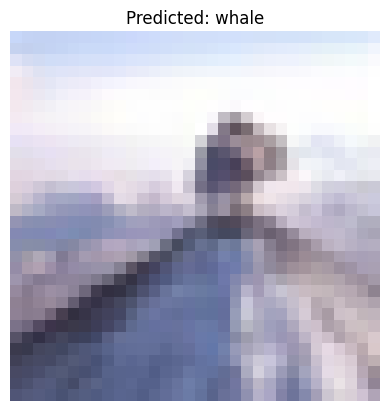

In [ ]:
sample = X_test[0]

prediction = model.predict(
    sample.reshape(1,32,32,3)
)

predicted_class = np.argmax(prediction)

plt.imshow(sample)
plt.title(
    f"Predicted: {class_names[predicted_class]}"
)
plt.axis('off')
plt.show()

Saving Screenshot 2026-06-05 180301.png to Screenshot 2026-06-05 180301.png


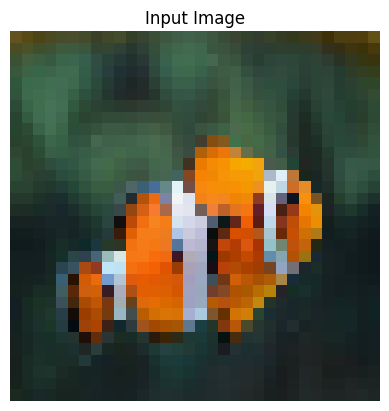

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Class: aquarium_fish
Confidence: 65.35599 %


In [ ]:
from google.colab import files
import cv2

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img = cv2.resize(img, (32,32))

plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()

img = img / 255.0

img_input = img.reshape(1,32,32,3)

prediction = model.predict(img_input)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction) * 100

print("Predicted Class:",
      class_names[predicted_class])

print("Confidence:",
      confidence,"%")
